In [1]:
import os
import time
import warnings
from dataclasses import dataclass, field

import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32 

USE_TF32 = False
torch.backends.cuda.matmul.allow_tf32 = USE_TF32
torch.backends.cudnn.allow_tf32 = USE_TF32

P_OVERSAMPLE, Q_SUBSPACE, TOL, MAX_ITER = 20, 2, 1e-4, 100

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

print(f"torch {torch.__version__}  device={DEVICE}  dtype={DTYPE}")
if DEVICE.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"{p.name} | {p.total_memory / 1e9:.1f} GB VRAM | SM {p.major}.{p.minor} "
          f"| {p.multi_processor_count} SMs")
else:
    print("WARNING: no CUDA device found -- everything below still runs, on the CPU.")

torch 2.13.0+cu130  device=cuda  dtype=torch.float32
NVIDIA GeForce RTX 4060 Laptop GPU | 8.6 GB VRAM | SM 8.9 | 24 SMs


In [2]:
def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


class Timer:
    "Wall-clock timing with a CUDA barrier at both ends."
    def __enter__(self):
        sync()
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        sync()
        self.dt = time.perf_counter() - self.t0


def vram(tag=""):
    if DEVICE.type != "cuda":
        return
    a = torch.cuda.memory_allocated() / 1e9
    p = torch.cuda.max_memory_allocated() / 1e9
    print(f"  [{tag}] allocated {a:.2f} GB, peak {p:.2f} GB")


def reset_peak():
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()


def free_vram():
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


def gen(seed=SEED):
    return torch.Generator(device=DEVICE).manual_seed(seed)

In [3]:
# Cell 4 — randomized range finder, in-core and streaming

def _qr(A):
    return torch.linalg.qr(A, mode="reduced")[0]


def randomized_range_finder(X, rank, oversample=P_OVERSAMPLE, n_subspace=Q_SUBSPACE, g=None):
    "Q with orthonormal columns such that X ~= Q Q^T X. X must already be on the device."
    n = X.shape[1]
    ell = int(min(rank + oversample, min(X.shape)))
    Omega = torch.rand((n, ell), device=X.device, dtype=X.dtype, generator=g)   # Remark 1
    Q = _qr(X @ Omega)                                                          # Eq. 4
    for _ in range(n_subspace):                                                 # Remark 3
        Z = _qr(X.T @ Q)
        Q = _qr(X @ Z)
    return Q


def compress(X, rank, oversample=P_OVERSAMPLE, n_subspace=Q_SUBSPACE, g=None):
    Q = randomized_range_finder(X, rank, oversample, n_subspace, g)
    return Q, Q.T @ X                                                           # Eq. 6


def compress_streaming(X_host, rank, oversample=P_OVERSAMPLE, n_subspace=Q_SUBSPACE,
                       block=4096, g=None):
    "X_host stays in CPU memory (torch tensor, numpy array or memmap). Only Q and B reach the GPU."
    m, n = X_host.shape
    ell = int(min(rank + oversample, min(m, n)))
    Omega = torch.rand((n, ell), device=DEVICE, dtype=DTYPE, generator=g)

    def blocks():
        for s in range(0, m, block):
            Xb = torch.as_tensor(np.asarray(X_host[s:s + block]), dtype=DTYPE)
            yield s, Xb.to(DEVICE, non_blocking=True)

    Y = torch.empty((m, ell), device=DEVICE, dtype=DTYPE)
    for s, Xb in blocks():
        Y[s:s + Xb.shape[0]] = Xb @ Omega
    Q = _qr(Y)

    for _ in range(n_subspace):
        Zt = torch.zeros((n, ell), device=DEVICE, dtype=DTYPE)
        for s, Xb in blocks():
            Zt += Xb.T @ Q[s:s + Xb.shape[0]]
        Z = _qr(Zt)
        for s, Xb in blocks():
            Y[s:s + Xb.shape[0]] = Xb @ Z
        Q = _qr(Y)

    B = torch.zeros((ell, n), device=DEVICE, dtype=DTYPE)
    for s, Xb in blocks():
        B += Q[s:s + Xb.shape[0]].T @ Xb
    return Q, B

In [4]:
# Cell 5 — initialization, error metrics, stopping rule

def init_factors(m, n, rank, X, g=None):
    "Remark 4: Gaussian entries with negatives clipped to zero, scaled to match X."
    W = torch.randn((m, rank), device=X.device, dtype=X.dtype, generator=g).clamp_min_(0)
    H = torch.randn((rank, n), device=X.device, dtype=X.dtype, generator=g).clamp_min_(0)
    scale = (X.abs().mean() / rank).sqrt()
    return W * scale + 1e-8, H * scale + 1e-8


def revive(M, dim):
    "Resurrect all-zero columns/rows without a host sync (a dead HALS component never recovers)."
    s = M.sum(dim=dim, keepdim=True)
    return torch.where(s == 0, torch.full_like(M, 1e-16), M)


def relative_error(X, W, H, chunk=8192):
    "||X - WH||_F / ||X||_F, accumulated in float64 even when the factors are float32."
    num = 0.0
    for s in range(0, X.shape[1], chunk):
        R = X[:, s:s + chunk].double() - W.double() @ H[:, s:s + chunk].double()
        num += float((R * R).sum())
    return num ** 0.5 / float(X.double().norm())


def _residual(norm_sq, cross, WtW, HHt):
    val = norm_sq - 2.0 * cross + float((WtW.double() * HHt.double()).sum())
    return max(val, 0.0) ** 0.5


def _converged(prev, curr, tol):
    return prev is not None and abs(prev - curr) <= tol * max(prev, 1e-30)


@dataclass
class NMFResult:
    W: torch.Tensor
    H: torch.Tensor
    errors: list = field(default_factory=list)
    n_iter: int = 0
    time: float = 0.0
    peak_gb: float = 0.0

    def summary(self, X):
        return dict(time=round(self.time, 3), iters=self.n_iter,
                    error=round(relative_error(X, self.W, self.H), 4))

In [5]:
# Cell 6 — deterministic HALS (baseline for all speedups)

def hals_nmf(X, rank, max_iter=MAX_ITER, tol=TOL, seed=SEED, check_every=1, verbose=False):
    g = gen(seed)
    m, n = X.shape
    W, H = init_factors(m, n, rank, X, g)
    norm_sq = float((X.double() ** 2).sum())
    normX = norm_sq ** 0.5
    errors, prev = [], None
    reset_peak()

    with Timer() as t:
        for it in range(max_iter):
            XHt = X @ H.T                       # O(mnk) -- the expensive one
            HHt = H @ H.T
            for j in range(rank):               # Eq. 14
                W[:, j] = (W[:, j] + (XHt[:, j] - W @ HHt[:, j]) / (HHt[j, j] + 1e-12)).clamp_min_(0)
            W = revive(W, 0)

            XtW = X.T @ W                       # O(mnk)
            WtW = W.T @ W
            for j in range(rank):               # Eq. 15
                H[j, :] = (H[j, :] + (XtW[:, j] - H.T @ WtW[:, j]) / (WtW[j, j] + 1e-12)).clamp_min_(0)
            H = revive(H, 1)

            if it % check_every == 0 or it == max_iter - 1:
                HHt = H @ H.T
                cross = float((XtW.double() * H.T.double()).sum())
                err = _residual(norm_sq, cross, WtW, HHt) / normX
                errors.append(err)
                if verbose and it % 10 == 0:
                    print(f"  det  iter {it:3d}  rel.err {err:.6f}")
                if _converged(prev, err, tol):
                    break
                prev = err

    peak = torch.cuda.max_memory_allocated() / 1e9 if DEVICE.type == "cuda" else 0.0
    return NMFResult(W, H, errors, len(errors), t.dt, peak)

In [6]:
# Cell 7 — randomized HALS (Eqs. 19-21)

def rnmf_hals(X, rank, oversample=P_OVERSAMPLE, n_subspace=Q_SUBSPACE, max_iter=MAX_ITER,
              tol=TOL, seed=SEED, projection="column", check_every=1, verbose=False,
              precomputed=None, X_for_init=None):
    g = gen(seed)
    reset_peak()

    with Timer() as t:
        if precomputed is None:
            Q, B = compress(X, rank, oversample, n_subspace, g)
            norm_sq = float((X.double() ** 2).sum())
        else:
            Q, B, norm_sq = precomputed
        m = Q.shape[0]
        n = B.shape[1]

        ref = X if X is not None else B
        W0, H = init_factors(m, n, rank, ref, g)
        Wt = Q.T @ W0

        normX = norm_sq ** 0.5
        normB_sq = float((B.double() ** 2).sum())
        offset_sq = max(norm_sq - normB_sq, 0.0)        # ||X - QB||^2, constant
        errors, prev = [], None

        for it in range(max_iter):
            BtWt = B.T @ Wt                             # Eq. 19
            WtWt = Wt.T @ Wt
            for j in range(rank):
                H[j, :] = (H[j, :] + (BtWt[:, j] - H.T @ WtWt[:, j]) / (WtWt[j, j] + 1e-12)).clamp_min_(0)
            H = revive(H, 1)

            BHt = B @ H.T                               # Eq. 20
            HHt = H @ H.T
            for j in range(rank):
                Wt[:, j] = Wt[:, j] + (BHt[:, j] - Wt @ HHt[:, j]) / (HHt[j, j] + 1e-12)
                if projection == "column":              # Eq. 21, literal
                    Wt[:, j] = Q.T @ (Q @ Wt[:, j]).clamp_min_(0)
            if projection == "sweep":                   # Eq. 21, batched into 2 GEMMs
                Wt = Q.T @ (Q @ Wt).clamp_min_(0)

            if it % check_every == 0 or it == max_iter - 1:
                WtWt = Wt.T @ Wt
                cross = float((BHt.double() * Wt.double()).sum())
                resB = max(normB_sq - 2.0 * cross + float((WtWt.double() * HHt.double()).sum()), 0.0)
                track = resB ** 0.5 / normB_sq ** 0.5
                errors.append(max(offset_sq + resB, 0.0) ** 0.5 / normX)
                if verbose and it % 10 == 0:
                    print(f"  rand iter {it:3d}  compressed rel.err {track:.6f}")
                if _converged(prev, track, tol):
                    break
                prev = track

        W = (Q @ Wt).clamp_min_(0)

    peak = torch.cuda.max_memory_allocated() / 1e9 if DEVICE.type == "cuda" else 0.0
    return NMFResult(W, H, errors, len(errors), t.dt, peak)

In [7]:
# Cell 8 — compressed MU baseline (Tepper & Sapiro, 2016), GPU port

def compressed_mu(X, rank, oversample=P_OVERSAMPLE, n_subspace=Q_SUBSPACE, max_iter=5000,
                  tol=TOL, seed=SEED, check_every=25):
    g = gen(seed)
    m, n = X.shape
    reset_peak()
    with Timer() as t:
        L = randomized_range_finder(X, rank, oversample, n_subspace, g)
        R = randomized_range_finder(X.T, rank, oversample, n_subspace, g)
        XL, XR = L.T @ X, X @ R
        W, H = init_factors(m, n, rank, X, g)
        errors, prev, it = [], None, 0
        for it in range(max_iter):
            WL = L.T @ W
            H = H * ((WL.T @ XL).clamp_min(0) / ((WL.T @ WL) @ H + 1e-9))
            HR = H @ R
            W = W * ((XR @ HR.T).clamp_min(0) / (W @ (HR @ HR.T) + 1e-9))
            if it % check_every == 0 or it == max_iter - 1:
                err = relative_error(X, W, H)
                errors.append(err)
                if _converged(prev, err, tol):
                    break
                prev = err
    peak = torch.cuda.max_memory_allocated() / 1e9 if DEVICE.type == "cuda" else 0.0
    return NMFResult(W, H, errors, it + 1, t.dt, peak)

In [8]:
# Cell 9 — sanity checks

g0 = gen(0)
m, n, r = 8000, 900, 20
Wtrue = torch.randn(m, r, device=DEVICE, dtype=DTYPE, generator=g0).clamp_min_(0)
Htrue = torch.randn(r, n, device=DEVICE, dtype=DTYPE, generator=g0).clamp_min_(0)
Xt = Wtrue @ Htrue

Q, B = compress(Xt, r, g=gen(1))
lhs = float(((Xt - Q @ B).double() ** 2).sum())
nx, nb = float((Xt.double() ** 2).sum()), float((B.double() ** 2).sum())
print(f"(a) direct ||X-QB||^2 / ||X||^2 = {lhs / nx:.3e}")
print(f"    cancellation in ||X||^2-||B||^2: {abs(nx - nb) / nx:.2e} relative "
      f"(float32 eps = {torch.finfo(torch.float32).eps:.1e})")
print(f"    Q^T Q = I: {torch.allclose(Q.T @ Q, torch.eye(Q.shape[1], device=DEVICE, dtype=DTYPE), atol=1e-4)}")

det = hals_nmf(Xt, r)
rnd = rnmf_hals(Xt, r)
print(f"(b) min(W)={float(rnd.W.min()):.1e}  min(H)={float(rnd.H.min()):.1e}")
print(f"(c) rank-{r} recovery, randomized rel.err = {relative_error(Xt, rnd.W, rnd.H):.2e}")
print(f"(d) det {det.time:.2f}s ({det.n_iter} it) | rand {rnd.time:.2f}s ({rnd.n_iter} it) "
      f"| speedup x{det.time / rnd.time:.1f}")

Qs, Bs = compress_streaming(Xt.cpu(), r, block=2048, g=gen(1))
print(f"(e) streaming vs in-core compression error: "
      f"{float((Xt - Qs @ Bs).norm() / Xt.norm()):.3e} vs {float((Xt - Q @ B).norm() / Xt.norm()):.3e}")

assert float(rnd.W.min()) >= 0 and float(rnd.H.min()) >= 0
assert relative_error(Xt, rnd.W, rnd.H) < 1e-2
vram("after checks")
print("\nAll checks passed.")
del Xt, Wtrue, Htrue, Q, B, Qs, Bs, det, rnd
free_vram()

(a) direct ||X-QB||^2 / ||X||^2 = 4.423e-14
    cancellation in ||X||^2-||B||^2: 3.27e-08 relative (float32 eps = 1.2e-07)
    Q^T Q = I: True
(b) min(W)=0.0e+00  min(H)=0.0e+00
(c) rank-20 recovery, randomized rel.err = 1.11e-04
(d) det 0.46s (100 it) | rand 0.23s (42 it) | speedup x2.0
(e) streaming vs in-core compression error: 2.629e-07 vs 2.103e-07
  [after checks] allocated 0.04 GB, peak 0.22 GB

All checks passed.


In [9]:
# Cell 10 — shared helpers for the experiments

def to_dev(A):
    "numpy array -> device tensor in the configured dtype."
    return torch.as_tensor(np.ascontiguousarray(A), dtype=DTYPE, device=DEVICE)


def np_(T):
    return T.detach().float().cpu().numpy()


def plot_gallery(basis, image_shape, n_row=4, n_col=4, title="", cmap="Reds", figsize=(4.2, 4.2)):
    A = np_(basis)
    fig, axes = plt.subplots(n_row, n_col, figsize=figsize)
    for i, ax in enumerate(axes.ravel()):
        ax.axis("off")
        if i < A.shape[1]:
            ax.imshow(A[:, i].reshape(image_shape), cmap=cmap)
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()


def make_table(results, X, baseline="Deterministic HALS"):
    base_t = results[baseline].time
    head = ("Method", "Time (s)", "Speedup", "Iterations", "Error", "Peak VRAM (GB)")
    rows = []
    for name, res in results.items():
        s = res.summary(X)
        speed = "-" if name == baseline else f"{base_t / res.time:.1f}"
        rows.append((name, f"{s['time']:.2f}", speed, str(s["iters"]),
                     f"{s['error']:.3f}", f"{res.peak_gb:.2f}"))
    widths = [max(len(r[i]) for r in rows + [head]) for i in range(len(head))]
    line = "  ".join(h.ljust(w) for h, w in zip(head, widths))
    print(line); print("-" * len(line))
    for r in rows:
        print("  ".join(c.ljust(w) for c, w in zip(r, widths)))


def svd_baseline(X, rank):
    with Timer() as t:
        U, S, Vh = torch.linalg.svd(X, full_matrices=False)
        U, S, Vh = U[:, :rank], S[:rank], Vh[:rank]
    err = float(((X - (U * S) @ Vh).double() ** 2).sum()) ** 0.5 / float(X.double().norm())
    return U, S, Vh, t.dt, err

In [10]:
# Cell 11 — load MNIST (offline fallback to 8x8 digits)

def load_mnist(n_train=60000, n_test=10000):
    try:
        from sklearn.datasets import fetch_openml
        d = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
        Xall, yall = d.data.astype(np.float32) / 255.0, d.target.astype(int)
        Xtr, ytr = Xall[:n_train].T, yall[:n_train]
        Xte, yte = Xall[n_train:n_train + n_test].T, yall[n_train:n_train + n_test]
        shape = (28, 28)
        print(f"MNIST: train {Xtr.shape}, test {Xte.shape}")
    except Exception as exc:
        from sklearn.datasets import load_digits
        from sklearn.model_selection import train_test_split
        print(f"[fallback] MNIST unavailable ({type(exc).__name__}); using 8x8 digits.")
        d = load_digits()
        a, b, ya, yb = train_test_split(d.data / 16.0, d.target, test_size=0.3,
                                        random_state=SEED, stratify=d.target)
        Xtr, ytr, Xte, yte, shape = a.T, ya, b.T, yb, (8, 8)
    return to_dev(Xtr), ytr, to_dev(Xte), yte, shape


X_tr, y_tr, X_te, y_te, IMG_SHAPE = load_mnist()
K_DIGITS = 16
vram("MNIST on device")

MNIST: train (784, 60000), test (784, 10000)
  [MNIST on device] allocated 0.23 GB, peak 0.23 GB


In [11]:
# Cell 12 — Table 1

res_mnist = {
    "Deterministic HALS": hals_nmf(X_tr, K_DIGITS),
    "Randomized HALS": rnmf_hals(X_tr, K_DIGITS),
    "Compressed MU": compressed_mu(X_tr, K_DIGITS),
}
print("Table 1 -- MNIST, k = 16\n")
make_table(res_mnist, X_tr)

U, S, Vh, t_svd, e_svd = svd_baseline(X_tr, K_DIGITS)
print(f"\nSVD reference: {t_svd:.2f}s, error {e_svd:.3f}")

Table 1 -- MNIST, k = 16

Method              Time (s)  Speedup  Iterations  Error  Peak VRAM (GB)
------------------------------------------------------------------------
Deterministic HALS  0.55      -        55          0.546  0.26          
Randomized HALS     0.89      0.6      79          0.560  0.99          
Compressed MU       1.54      0.4      926         0.547  0.65          

SVD reference: 0.17s, error 0.494


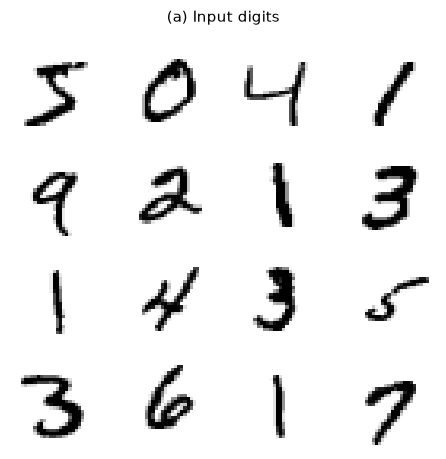

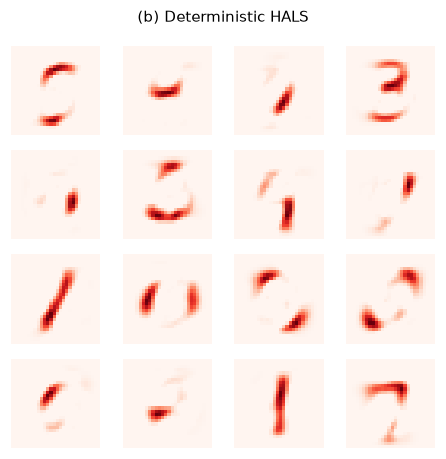

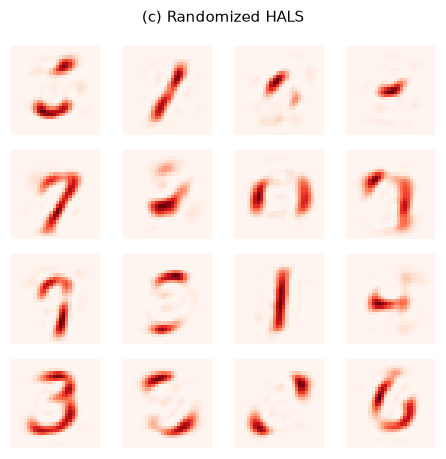

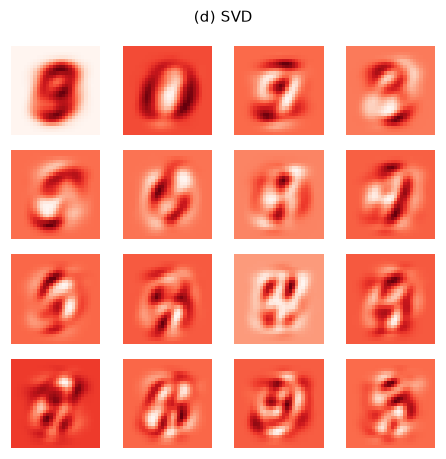

Deterministic HALS     zeros in W: 0.73
Randomized HALS        zeros in W: 0.43
SVD                    negative entries: 0.43


In [12]:
# Cell 13 — Figure 1

plot_gallery(X_tr[:, :16], IMG_SHAPE, title="(a) Input digits", cmap="gray_r")
plot_gallery(res_mnist["Deterministic HALS"].W, IMG_SHAPE, title="(b) Deterministic HALS")
plot_gallery(res_mnist["Randomized HALS"].W, IMG_SHAPE, title="(c) Randomized HALS")
plot_gallery(U, IMG_SHAPE, title="(d) SVD")
plt.show()

for name in ("Deterministic HALS", "Randomized HALS"):
    W = res_mnist[name].W
    print(f"{name:22s} zeros in W: {float((W < 1e-10).float().mean()):.2f}")
print(f"{'SVD':22s} negative entries: {float((U < 0).float().mean()):.2f}")

In [13]:
# Cell 14 — Table 2: kNN on the learned features (sklearn runs on CPU; move features across once)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_recall_fscore_support


def project_nonneg(W, X):
    "min_h ||x - W h||, h >= 0, solved on the GPU (clipped least squares)."
    return torch.linalg.lstsq(W, X).solution.clamp_min_(0)


def normalize_factors(W, H):
    "Fix scale indeterminacy: unit-norm columns of W, scale absorbed into H."
    nw = W.norm(dim=0, keepdim=True).clamp_min(1e-12)
    return W / nw, H * nw.T


def classify(train_feats, test_feats, ytr, yte, n_neighbors=3):
    knn = KNeighborsClassifier(n_neighbors=n_neighbors).fit(np_(train_feats).T, ytr)
    out = {}
    for tag, F, y in (("train", train_feats, ytr), ("test", test_feats, yte)):
        pred = knn.predict(np_(F).T)
        p, r, f1, _ = precision_recall_fscore_support(y, pred, average="weighted", zero_division=0)
        out[tag] = (p, r, f1)
    return out


# Report the component-norm spread that motivates the normalization.
for name in ("Deterministic HALS", "Randomized HALS", "Compressed MU"):
    nw = res_mnist[name].W.norm(dim=0)
    print(f"{name:22s} component-norm spread: {float(nw.max() / nw.min().clamp_min(1e-12)):.1f}x")
print()

rows = {}
for name in ("Deterministic HALS", "Randomized HALS", "Compressed MU"):
    W, H = normalize_factors(res_mnist[name].W, res_mnist[name].H)
    rows[name] = classify(project_nonneg(W, X_tr),      # same projection on both splits
                          project_nonneg(W, X_te), y_tr, y_te)
rows["SVD"] = classify(U.T @ X_tr, U.T @ X_te, y_tr, y_te)

print("Table 2 -- kNN (k=3) on rank-16 features\n")
for split in ("train", "test"):
    print(f"({'a' if split == 'train' else 'b'}) {split.capitalize()} data.")
    print(f"{'':22s}{'Precision':>11}{'Recall':>9}{'F1-score':>10}")
    for name, v in rows.items():
        p, r, f1 = v[split]
        print(f"{name:22s}{p:11.2f}{r:9.2f}{f1:10.2f}")
    print()

Deterministic HALS     component-norm spread: 6.7x
Randomized HALS        component-norm spread: 846.4x
Compressed MU          component-norm spread: 4385.8x

Table 2 -- kNN (k=3) on rank-16 features

(a) Train data.
                        Precision   Recall  F1-score
Deterministic HALS           0.96     0.96      0.96
Randomized HALS              0.95     0.95      0.95
Compressed MU                0.97     0.97      0.97
SVD                          0.98     0.98      0.98

(b) Test data.
                        Precision   Recall  F1-score
Deterministic HALS           0.93     0.93      0.93
Randomized HALS              0.92     0.92      0.92
Compressed MU                0.94     0.94      0.94
SVD                          0.96     0.96      0.96



Yale B: 1728 images of (168, 192)
X_faces: (32256, 1728)

Table 3 -- faces, k = 16

Method              Time (s)  Speedup  Iterations  Error  Peak VRAM (GB)
------------------------------------------------------------------------
Deterministic HALS  0.47      -        50          0.355  0.73          
Randomized HALS     0.69      0.7      58          0.362  1.62          
Compressed MU       1.61      0.3      901         0.356  2.08          


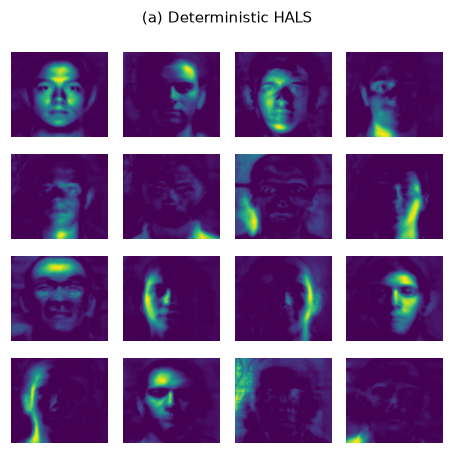

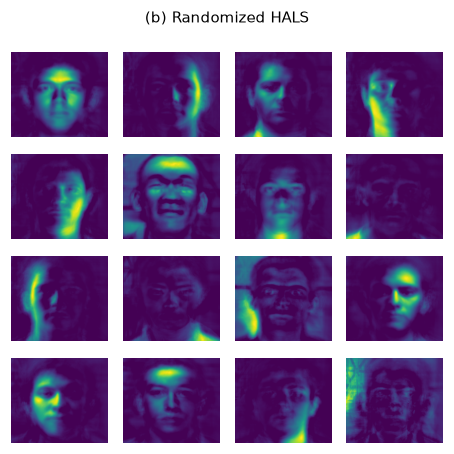

In [23]:
# Cell 15 — faces
YALE_DIR = "cropped"    # Extended Yale B, cropped 192x168 .pgm files

def load_faces(yale_dir=YALE_DIR, downsample=1):
    if yale_dir and os.path.isdir(yale_dir):
        from PIL import Image
        paths = sorted(os.path.join(root, f)
                       for root, _, files in os.walk(yale_dir)
                       for f in files
                       if f.lower().endswith(".pgm") and "_P00A" in f)
        A = np.stack([np.asarray(Image.open(p), dtype=np.float32)[::downsample, ::downsample]
                      for p in paths])
        print(f"Yale B: {A.shape[0]} images of {A.shape[1:]}")
        return to_dev(A.reshape(A.shape[0], -1).T / 255.0), A.shape[1:]
    try:
        from sklearn.datasets import fetch_olivetti_faces
        f = fetch_olivetti_faces(shuffle=False)
        print(f"[fallback] Olivetti: {f.images.shape}")
        return to_dev(f.data.T), f.images.shape[1:]
    except Exception as exc:
        print(f"[fallback] synthesizing faces ({type(exc).__name__}).")
        rng = np.random.default_rng(SEED)
        h = w = 64
        yy, xx = np.mgrid[0:h, 0:w]
        parts = np.stack([np.exp(-((yy - rng.integers(10, h - 10)) ** 2
                                   + (xx - rng.integers(10, w - 10)) ** 2) / 128.0).ravel()
                          for _ in range(12)], axis=1)
        coef = np.maximum(rng.standard_normal((12, 1200)), 0)
        return to_dev(parts @ coef), (h, w)

X_faces, FACE_SHAPE = load_faces()
print(f"X_faces: {tuple(X_faces.shape)}")

K_FACES = 16
res_faces = {
    "Deterministic HALS": hals_nmf(X_faces, K_FACES),
    "Randomized HALS": rnmf_hals(X_faces, K_FACES),
    "Compressed MU": compressed_mu(X_faces, K_FACES),
}
print("\nTable 3 -- faces, k = 16\n")
make_table(res_faces, X_faces)
plot_gallery(res_faces["Deterministic HALS"].W, FACE_SHAPE, title="(a) Deterministic HALS", cmap="viridis")
plot_gallery(res_faces["Randomized HALS"].W, FACE_SHAPE, title="(b) Randomized HALS", cmap="viridis")
plt.show()

In [25]:
import inspect
print(inspect.getsource(gen))

def gen(seed=SEED):
    return torch.Generator(device=DEVICE).manual_seed(seed)



In [ ]:
# Cell 15b — Table 3 on CPU (the paper's hardware regime)
import torch, os
torch.set_num_threads(os.cpu_count())
print(f"CPU threads: {torch.get_num_threads()}")

_saved_device = DEVICE          # whatever Cell 1 named it
DEVICE = torch.device("cpu")

X_faces_cpu = X_faces.cpu()
print(f"X_faces_cpu: {tuple(X_faces_cpu.shape)}")

res_faces_cpu = {
    "Deterministic HALS": hals_nmf(X_faces_cpu, K_FACES),
    "Randomized HALS": rnmf_hals(X_faces_cpu, K_FACES),
    "Compressed MU": compressed_mu(X_faces_cpu, K_FACES),
}
print("\nTable 3 (CPU) -- faces, k = 16\n")
make_table(res_faces_cpu, X_faces_cpu)

DEVICE = _saved_device

CPU threads: 24
X_faces_cpu: (32256, 1728)


[substitute] Indian Pines: 200 bands x 21025 pixels (145x145)
X_hsi: (200, 21025)

Table 4 -- hyperspectral, k = 4

Method              Time (s)  Speedup  Iterations  Error  Peak VRAM (GB)
------------------------------------------------------------------------
Deterministic HALS  0.20      -        67          0.047  0.68          
Randomized HALS     0.28      0.7      82          0.037  0.75          
Compressed MU       3.47      0.1      5000        0.036  0.74          


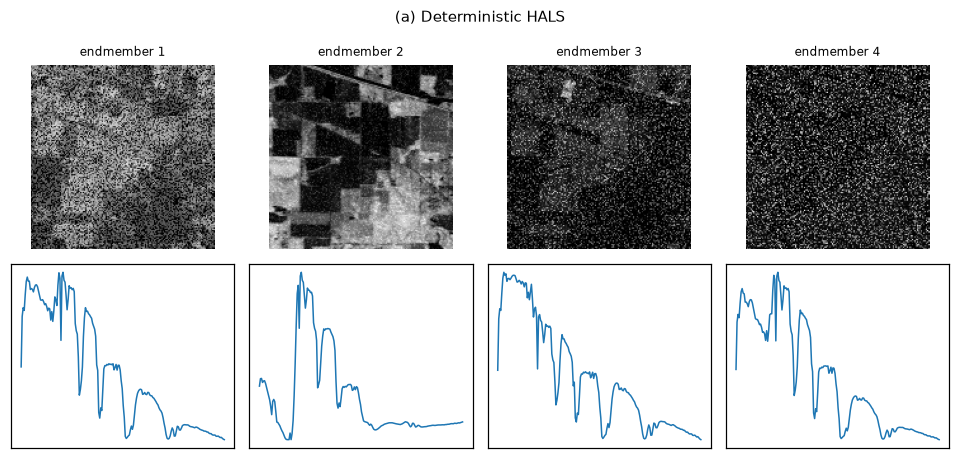

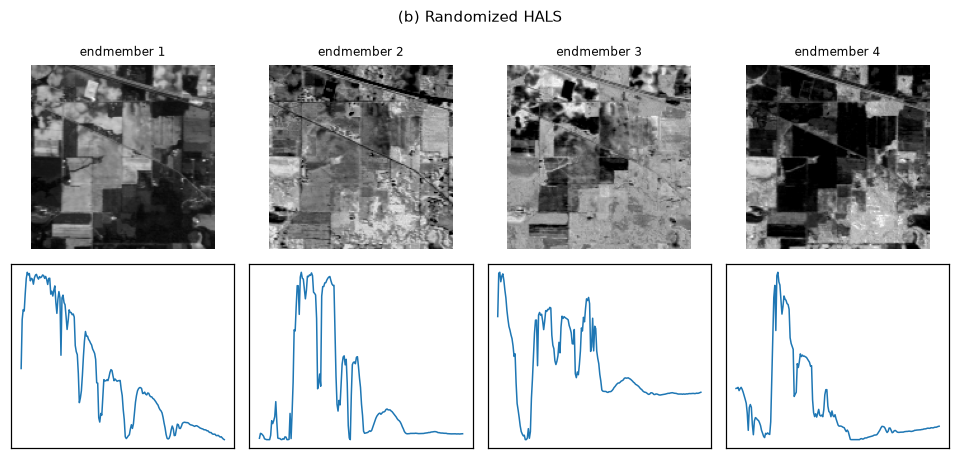

In [15]:
# Cell 16 — hyperspectral unmixing (bands x pixels)

URBAN_MAT  = None   # paper's scene: Urban_R162.mat (site unreachable)
INDIAN_NPY = r"D:\python\deep learning\rnmf\indianpinearray.npy"   # real, different scene


def load_urban(path=URBAN_MAT, indian=INDIAN_NPY):
    if path and os.path.isfile(path):
        from scipy.io import loadmat
        mat = loadmat(path)
        Y = np.asarray(mat["Y"], dtype=np.float32)
        nRow, nCol = int(np.squeeze(mat.get("nRow", 307))), int(np.squeeze(mat.get("nCol", 307)))
        print(f"Urban: {Y.shape[0]} bands x {Y.shape[1]} pixels")
        return to_dev(Y / Y.max()), (nRow, nCol)

    if indian and os.path.isfile(indian):
        cube = np.load(indian).astype(np.float32)
        if cube.ndim == 3:
            nRow, nCol, bands = cube.shape
            Y = cube.reshape(-1, bands).T
        else:                                   # already pixels x bands
            nRow = nCol = int(round(cube.shape[0] ** 0.5))
            bands = cube.shape[1]
            Y = cube.T
        Y = np.clip(Y, 0, None)
        print(f"[substitute] Indian Pines: {bands} bands x {Y.shape[1]} pixels ({nRow}x{nCol})")
        return to_dev(Y / Y.max()), (nRow, nCol)

    print("[fallback] synthesizing a 4-endmember cube.")
    rng = np.random.default_rng(SEED)
    nRow = nCol = 200
    bands = 162
    x = np.linspace(0, 1, bands)
    E = np.stack([np.exp(-((x - .2) ** 2) / .01) + .3 * x,
                  np.exp(-((x - .55) ** 2) / .005) + .5 * np.exp(-((x - .8) ** 2) / .02),
                  .8 * np.exp(-((x - .7) ** 2) / .03) + .2,
                  np.clip(1 - x, 0, None) + .15], axis=1)
    yy, xx = np.mgrid[0:nRow, 0:nCol] / nRow
    A = np.stack([np.exp(-((yy - .3) ** 2 + (xx - .3) ** 2) / .05),
                  np.exp(-((yy - .7) ** 2 + (xx - .6) ** 2) / .04),
                  (np.sin(6 * np.pi * xx) ** 2) * (yy > .5),
                  np.exp(-((xx - .85) ** 2) / .01)], axis=0).reshape(4, -1)
    A /= A.sum(0, keepdims=True) + 1e-12
    Y = E @ A + .01 * np.abs(rng.standard_normal((bands, nRow * nCol)))
    return to_dev(Y), (nRow, nCol)


X_hsi, HSI_SHAPE = load_urban()
print(f"X_hsi: {tuple(X_hsi.shape)}")

K_HSI = 4
res_hsi = {
    "Deterministic HALS": hals_nmf(X_hsi, K_HSI),
    "Randomized HALS": rnmf_hals(X_hsi, K_HSI, oversample=10),
    "Compressed MU": compressed_mu(X_hsi, K_HSI, oversample=10),
}
print(f"\nTable 4 -- hyperspectral, k = {K_HSI}\n")
make_table(res_hsi, X_hsi)


def plot_unmixing(res, shape, title):
    W, H = np_(res.W), np_(res.H)
    order = np.argsort(-H.sum(1))
    fig, axes = plt.subplots(2, W.shape[1], figsize=(2.2 * W.shape[1], 4.2))
    for c, j in enumerate(order):
        axes[0, c].imshow(H[j].reshape(shape), cmap="gray"); axes[0, c].axis("off")
        axes[0, c].set_title(f"endmember {c + 1}", fontsize=8)
        axes[1, c].plot(W[:, j], lw=1); axes[1, c].set_xticks([]); axes[1, c].set_yticks([])
    fig.suptitle(title, fontsize=10); fig.tight_layout()


plot_unmixing(res_hsi["Deterministic HALS"], HSI_SHAPE, "(a) Deterministic HALS")
plot_unmixing(res_hsi["Randomized HALS"], HSI_SHAPE, "(b) Randomized HALS")
plt.show()
del X_faces, X_hsi
free_vram()

In [16]:
# Cell 17 — benchmark harness

FULL_SCALE = False
N_RUNS = 3
TARGET_RANKS = [5, 10, 20, 30, 40, 50]
TRUE_RANK = 50
DIMS = ([(50000, 3000), (20000, 15000)] if FULL_SCALE else [(20000, 1500), (8000, 6000)])


def make_lowrank(m, n, rank, noise=0.0, seed=SEED, device=DEVICE):
    g = torch.Generator(device=device).manual_seed(seed)
    W = torch.randn(m, rank, device=device, dtype=DTYPE, generator=g).clamp_min_(0)
    H = torch.randn(rank, n, device=device, dtype=DTYPE, generator=g).clamp_min_(0)
    X = W @ H
    if noise > 0:
        X = X + noise * X.std() * torch.randn(X.shape, device=device, dtype=DTYPE,
                                              generator=g).abs()
    del W, H
    return X


class use_device:
    "Temporarily retarget the global DEVICE so the same functions run on CPU or GPU."
    def __init__(self, dev):
        self.dev = dev

    def __enter__(self):
        self.prev = globals()["DEVICE"]
        globals()["DEVICE"] = self.dev

    def __exit__(self, *exc):
        globals()["DEVICE"] = self.prev


def benchmark(m, n, target_ranks=TARGET_RANKS, n_runs=N_RUNS, noise=0.0, with_cpu=True):
    devs = [("gpu", DEVICE)] + ([("cpu", torch.device("cpu"))]
                                if with_cpu and DEVICE.type == "cuda" else [])
    grid = {f"{alg}_{d}": [] for alg in ("det", "rand") for d, _ in devs}
    for k in target_ranks:
        acc = {key: {"t": [], "e": []} for key in grid}
        for run in range(n_runs):
            for dname, dev in devs:
                with use_device(dev):
                    X = make_lowrank(m, n, TRUE_RANK, noise=noise, seed=SEED + run, device=dev)
                    for alg, fn in (("det", hals_nmf), ("rand", rnmf_hals)):
                        res = fn(X, k, seed=SEED + run)
                        acc[f"{alg}_{dname}"]["t"].append(res.time)
                        acc[f"{alg}_{dname}"]["e"].append(relative_error(X, res.W, res.H))
                        del res
                    del X
                free_vram()
        for key in grid:
            if acc[key]["t"]:
                grid[key].append((k, float(np.mean(acc[key]["t"])), float(np.mean(acc[key]["e"]))))
        msg = "  ".join(f"{key} {np.mean(acc[key]['t']):6.2f}s" for key in grid if acc[key]["t"])
        print(f"  k={k:3d}  {msg}")
    return grid


STYLE = {"det_gpu": ("Deterministic HALS (GPU)", "tab:green", "s-"),
         "rand_gpu": ("Randomized HALS (GPU)", "tab:red", "o-"),
         "det_cpu": ("Deterministic HALS (CPU)", "tab:green", "s--"),
         "rand_cpu": ("Randomized HALS (CPU)", "tab:red", "o--")}


def plot_benchmark(grid, title):
    fig, axes = plt.subplots(3, 1, figsize=(4.6, 8.5), sharex=True)
    for key, series in grid.items():
        if not series:
            continue
        lab, col, sty = STYLE[key]
        ks = [s[0] for s in series]
        axes[0].semilogy(ks, [s[2] for s in series], sty, color=col, label=lab, ms=4)
        axes[1].semilogy(ks, [s[1] for s in series], sty, color=col, label=lab, ms=4)
    base = {s[0]: s[1] for s in (grid.get("det_cpu") or grid["det_gpu"])}
    for key in ("det_gpu", "rand_gpu", "rand_cpu"):
        if not grid.get(key):
            continue
        lab, col, sty = STYLE[key]
        ks = [s[0] for s in grid[key]]
        axes[2].plot(ks, [base[s[0]] / s[1] for s in grid[key]], sty, color=col, label=lab, ms=4)
    axes[0].set_ylabel("Relative error"); axes[0].legend(fontsize=7)
    axes[1].set_ylabel("Time in s")
    axes[2].set_ylabel("Speedup vs slowest baseline"); axes[2].set_xlabel("Target rank")
    axes[2].legend(fontsize=7)
    fig.suptitle(title, fontsize=10); fig.tight_layout()

Benchmarking 20000 x 1500 (clean)
  k=  5  det_gpu   0.37s  det_cpu   1.40s  rand_gpu   0.28s  rand_cpu   0.37s
  k= 10  det_gpu   0.63s  det_cpu   1.66s  rand_gpu   0.75s  rand_cpu   0.96s
  k= 20  det_gpu   1.19s  det_cpu   3.15s  rand_gpu   1.36s  rand_cpu   1.78s
  k= 30  det_gpu   1.63s  det_cpu   5.00s  rand_gpu   2.02s  rand_cpu   1.81s
  k= 40  det_gpu   1.05s  det_cpu   3.20s  rand_gpu   1.18s  rand_cpu   0.89s
  k= 50  det_gpu   1.22s  det_cpu   3.53s  rand_gpu   1.48s  rand_cpu   1.07s
Benchmarking 8000 x 6000 (clean)
  k=  5  det_gpu   0.03s  det_cpu   0.69s  rand_gpu   0.13s  rand_cpu   0.33s
  k= 10  det_gpu   0.40s  det_cpu   2.00s  rand_gpu   0.33s  rand_cpu   0.45s
  k= 20  det_gpu   0.60s  det_cpu   2.42s  rand_gpu   0.60s  rand_cpu   0.60s
  k= 30  det_gpu   0.74s  det_cpu   2.78s  rand_gpu   0.75s  rand_cpu   0.81s
  k= 40  det_gpu   1.00s  det_cpu   3.41s  rand_gpu   1.03s  rand_cpu   1.17s
  k= 50  det_gpu   1.12s  det_cpu   3.89s  rand_gpu   1.34s  rand_cpu   1.2

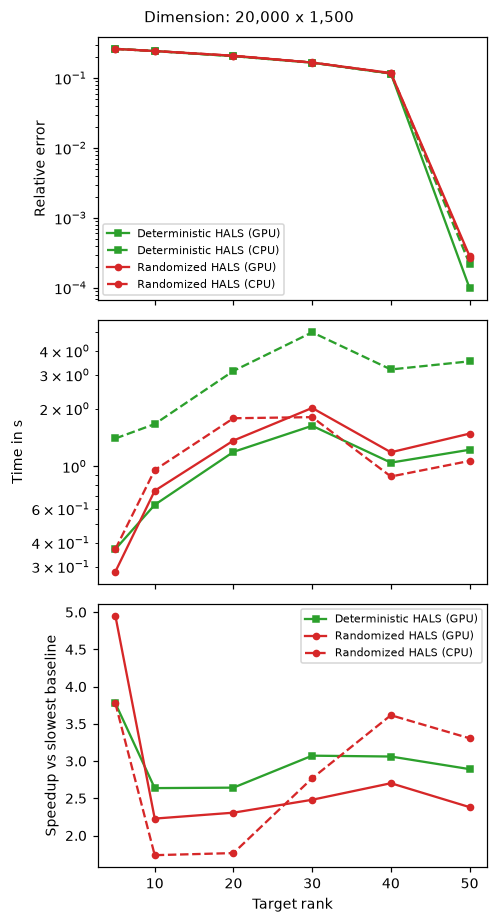

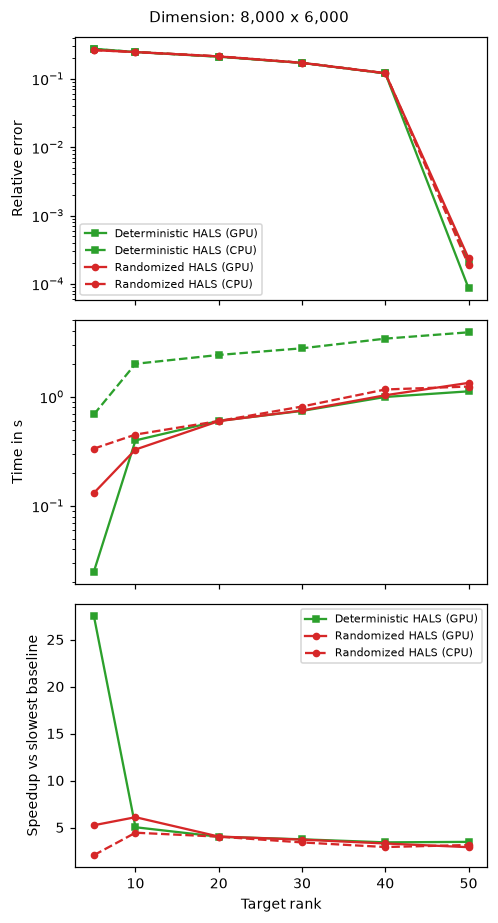

In [17]:
# Cell 18 — Figure 4: clean rank-50 matrices

for (m, n) in DIMS:
    print(f"Benchmarking {m} x {n} (clean)")
    plot_benchmark(benchmark(m, n, noise=0.0), f"Dimension: {m:,} x {n:,}")
plt.show()

Benchmarking 20000 x 1500 (10% noise)
  k=  5  det_gpu   0.22s  det_cpu   1.40s  rand_gpu   0.14s  rand_cpu   0.26s
  k= 10  det_gpu   0.38s  det_cpu   1.62s  rand_gpu   0.34s  rand_cpu   0.37s
  k= 20  det_gpu   0.56s  det_cpu   2.01s  rand_gpu   0.61s  rand_cpu   0.51s
  k= 30  det_gpu   0.80s  det_cpu   2.61s  rand_gpu   0.90s  rand_cpu   0.75s
  k= 40  det_gpu   0.96s  det_cpu   3.15s  rand_gpu   1.18s  rand_cpu   0.92s
  k= 50  det_gpu   0.80s  det_cpu   2.76s  rand_gpu   1.40s  rand_cpu   1.06s
Benchmarking 8000 x 6000 (10% noise)
  k=  5  det_gpu   0.02s  det_cpu   0.09s  rand_gpu   0.12s  rand_cpu   0.32s
  k= 10  det_gpu   0.41s  det_cpu   1.96s  rand_gpu   0.33s  rand_cpu   0.46s
  k= 20  det_gpu   0.61s  det_cpu   2.42s  rand_gpu   0.58s  rand_cpu   0.61s
  k= 30  det_gpu   0.74s  det_cpu   2.71s  rand_gpu   0.79s  rand_cpu   0.81s
  k= 40  det_gpu   0.90s  det_cpu   3.09s  rand_gpu   1.15s  rand_cpu   1.05s
  k= 50  det_gpu   0.77s  det_cpu   3.17s  rand_gpu   1.32s  rand_c

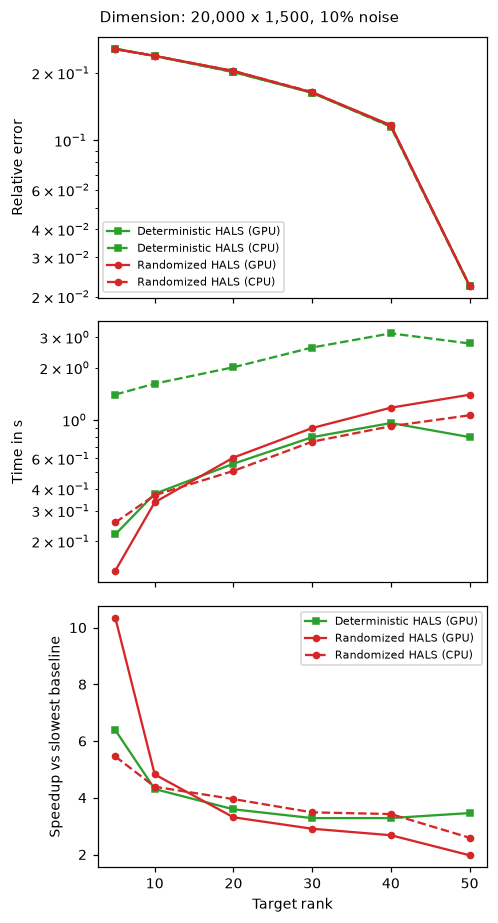

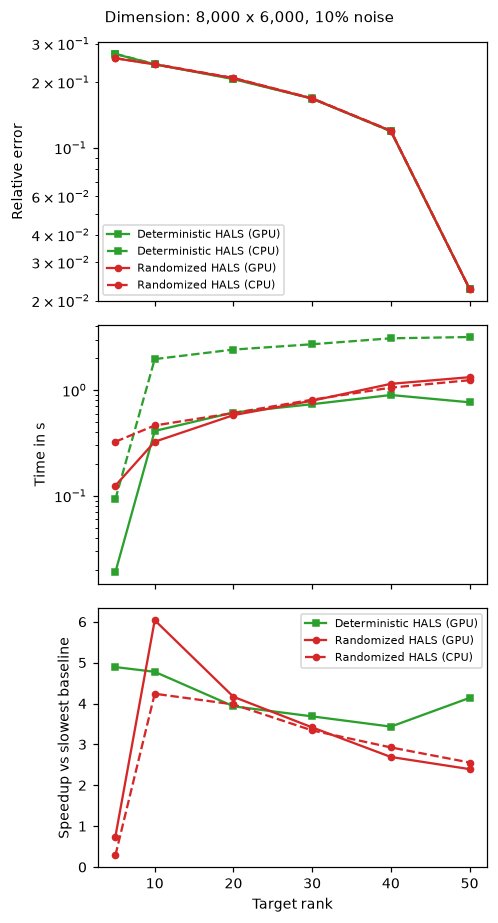

In [18]:
# Cell 19 — Figure 5: 10% white noise

for (m, n) in DIMS:
    print(f"Benchmarking {m} x {n} (10% noise)")
    plot_benchmark(benchmark(m, n, noise=0.1), f"Dimension: {m:,} x {n:,}, 10% noise")
plt.show()

In [19]:
# Cell 20 — dtype, TF32, projection mode, sync frequency

Xab = make_lowrank(20000, 1500, TRUE_RANK, noise=0.1)
k_ab = 30
print(f"{'setting':28s}{'time (s)':>10}{'rel. error':>14}")
print("-" * 52)

for mode in ("sweep", "column"):
    r = rnmf_hals(Xab, k_ab, projection=mode)
    print(f"{'projection=' + mode:28s}{r.time:>10.2f}{relative_error(Xab, r.W, r.H):>14.6f}")

for ce in (1, 5, 25):
    r = rnmf_hals(Xab, k_ab, check_every=ce)
    print(f"{'check_every=' + str(ce):28s}{r.time:>10.2f}{relative_error(Xab, r.W, r.H):>14.6f}")

if DEVICE.type == "cuda":
    for tf32 in (False, True):
        torch.backends.cuda.matmul.allow_tf32 = tf32
        r = rnmf_hals(Xab, k_ab)
        print(f"{'TF32=' + str(tf32):28s}{r.time:>10.2f}{relative_error(Xab, r.W, r.H):>14.6f}")
    torch.backends.cuda.matmul.allow_tf32 = USE_TF32

    X64 = Xab.double()
    r = rnmf_hals(X64, k_ab)
    print(f"{'dtype=float64':28s}{r.time:>10.2f}{relative_error(X64, r.W, r.H):>14.6f}")
    del X64

del Xab
free_vram()

setting                       time (s)    rel. error
----------------------------------------------------
projection=sweep                  0.91      0.170283
projection=column                 0.88      0.164935
check_every=1                     0.89      0.164935
check_every=5                     0.84      0.164935
check_every=25                    0.82      0.164935
TF32=False                        0.86      0.164935
TF32=True                         0.78      0.165081
dtype=float64                     1.05      0.164781


In [20]:
# Cell 21 — oversampling p and subspace iterations q (Remarks 2-3)

Xpq = make_lowrank(15000, 1200, TRUE_RANK, noise=0.1)
k_pq = 30
print(f"{'p':>4}{'q':>4}{'time (s)':>10}{'rel. error':>14}")
print("-" * 32)
for q in (0, 1, 2, 4):
    for p in (0, 10, 20, 50):
        r = rnmf_hals(Xpq, k_pq, oversample=p, n_subspace=q)
        print(f"{p:>4}{q:>4}{r.time:>10.2f}{relative_error(Xpq, r.W, r.H):>14.6f}")
ref = hals_nmf(Xpq, k_pq)
print(f"\ndeterministic: {ref.time:.2f}s, error {relative_error(Xpq, ref.W, ref.H):.6f}")
del Xpq, ref
free_vram()

   p   q  time (s)    rel. error
--------------------------------
   0   0      0.96      0.185338
  10   0      0.86      0.176409
  20   0      0.84      0.170155
  50   0      0.83      0.164431
   0   1      0.84      0.180470
  10   1      0.83      0.170799
  20   1      0.77      0.162543
  50   1      0.74      0.162736
   0   2      0.94      0.177738
  10   2      0.81      0.169096
  20   2      0.78      0.162560
  50   2      0.79      0.162927
   0   4      0.85      0.175119
  10   4      0.84      0.167090
  20   4      0.77      0.162561
  50   4      0.85      0.162324

deterministic: 0.68s, error 0.161486


In [21]:
# Cell 22 — out-of-core randomized NMF

OOC_M, OOC_N, OOC_K = 200000, 4000, 40      # 3.2 GB in float32; raise until it exceeds your VRAM

print(f"host matrix: {OOC_M} x {OOC_N} float32 = {OOC_M * OOC_N * 4 / 1e9:.2f} GB")
rng = np.random.default_rng(SEED)
Wh = np.maximum(rng.standard_normal((OOC_M, 50)), 0).astype(np.float32)
Hh = np.maximum(rng.standard_normal((50, OOC_N)), 0).astype(np.float32)
X_host = torch.from_numpy(Wh @ Hh)
if DEVICE.type == "cuda":
    X_host = X_host.pin_memory()          # pinned memory enables async H2D copies
del Wh, Hh

reset_peak()
with Timer() as t:
    Q, B = compress_streaming(X_host, OOC_K, block=8192, g=gen(1))
    norm_sq = float((X_host.double() ** 2).sum())
    res = rnmf_hals(None, OOC_K, precomputed=(Q, B, norm_sq))
print(f"streamed compression + factorization: {t.dt:.1f}s in {res.n_iter} iterations")
vram("out-of-core peak")
print(f"device tensors: Q {tuple(Q.shape)} + B {tuple(B.shape)} = "
      f"{(Q.numel() + B.numel()) * 4 / 1e9:.3f} GB, vs {X_host.numel() * 4 / 1e9:.2f} GB for X")

err = 0.0
for s in range(0, OOC_M, 8192):
    Xb = X_host[s:s + 8192].to(DEVICE, non_blocking=True)
    err += float(((Xb.double() - res.W[s:s + Xb.shape[0]].double() @ res.H.double()) ** 2).sum())
print(f"relative error: {err ** 0.5 / norm_sq ** 0.5:.5f}")

del X_host, Q, B, res
free_vram()

host matrix: 200000 x 4000 float32 = 3.20 GB
streamed compression + factorization: 15.0s in 96 iterations
  [out-of-core peak] allocated 0.53 GB, peak 0.59 GB
device tensors: Q (200000, 60) + B (60, 4000) = 0.049 GB, vs 3.20 GB for X
relative error: 0.12117
